In [1]:
%%time
import sys, os
path_dir = os.getcwd()
sys.path.append(path_dir+"/Functions")
import time # for time-basis conversions
from General_functions import *
from Cell_Values import *
from IO_functions import *
from IO_Plots import *
from Input_func import *

start_scope()
###################################################################
######################### Load Parameters #########################
###################################################################
Frozen_data = sio.loadmat('Data/'+datetime.datetime.now().strftime("%m-%d")+'/Frozen.mat', squeeze_me=True)
Params, Noise_frozen, Values, Synaps = Read_Input(Frozen_data)
###################################################################
######################## Initial Parameters #######################
###################################################################
dt = Params.dt
dt_rec = Params.dt_rec
width = Params.width
tau_noise = Params.tau_noise
exp_run = 10000*ms #Params.exp_run
###################################################################
########################## Cell Values ############################
###################################################################
Noise_I = Noise_frozen.Noise_I
I_recorded = Noise_frozen.I_recorded
period = Noise_frozen.period
IO_thresh = Values.IO_thresh
eqs_IO_syn = ''' I_c_pre = (0.00125*mS/cm**2)*(0.6*e**(-((Vd_pre/mvolt-Vd_post/mvolt)/50)**2) + 0.4)*(Vd_pre-Vd_post) : metre**-2*amp (summed)'''

def IO_cell_values(N_Cells_IO):
    class IO_Values:
        pass
    IO_Values.IO_V_Na = rand_params(55,mvolt ,N_Cells_IO,(1.0/N_Cells_IO))  #55*mvolt
    IO_Values.IO_V_K = rand_params(-75,mvolt ,N_Cells_IO,(1.0/N_Cells_IO))  #-75*mvolt
    IO_Values.IO_V_Ca = rand_params(120,mvolt ,N_Cells_IO,(1.0/N_Cells_IO))  #120*mvolt
    IO_Values.IO_V_l = rand_params(10,mvolt ,N_Cells_IO,(1.0/N_Cells_IO))  #10*mvolt 
    IO_Values.IO_V_h = rand_params(-43,mvolt ,N_Cells_IO,(1.0/N_Cells_IO))  #-43*mvolt 
    IO_Values.IO_Cm = rand_params(1,uF*cm**-2 ,N_Cells_IO,(0.1/N_Cells_IO))  #1*uF*cm**-2 
    IO_Values.IO_g_Na = rand_params(150,mS/cm**2,N_Cells_IO,(1.0/N_Cells_IO))  #150*mS/cm**2
    IO_Values.IO_g_Kdr = rand_params(9.0,mS/cm**2,N_Cells_IO,(0.1/N_Cells_IO))  #9.0*mS/cm**2
    IO_Values.IO_g_K_s = rand_params(5.0,mS/cm**2,N_Cells_IO,(0.1/N_Cells_IO))  #5.0*mS/cm**2
    IO_Values.IO_g_h = rand_params(0.12,mS/cm**2,N_Cells_IO,(0.01/N_Cells_IO))  #0.12*mS/cm**2
    IO_Values.IO_g_Ca_h = rand_params(4.5,mS/cm**2,N_Cells_IO,(0.1/N_Cells_IO))  #4.5*mS/cm**2
    IO_Values.IO_g_K_Ca = rand_params(35,mS/cm**2,N_Cells_IO,(0.5/N_Cells_IO))  #35*mS/cm**2
    IO_Values.IO_g_Na_a = rand_params(240,mS/cm**2,N_Cells_IO,(1.0/N_Cells_IO))  #240*mS/cm**2
    IO_Values.IO_g_K_a = rand_params(20,mS/cm**2,N_Cells_IO,(0.5/N_Cells_IO))  #20*mS/cm**2
    IO_Values.IO_g_ls = rand_params(0.016,mS/cm**2,N_Cells_IO,(0.001/N_Cells_IO))  #0.016*mS/cm**2
    IO_Values.IO_g_ld = rand_params(0.016,mS/cm**2,N_Cells_IO,(0.001/N_Cells_IO))  #0.016*mS/cm**2
    IO_Values.IO_g_la = rand_params(0.016,mS/cm**2,N_Cells_IO,(0.001/N_Cells_IO))  #0.016*mS/cm**2
    IO_Values.IO_g_int = rand_params(0.13,mS/cm**2,N_Cells_IO,(0.001/N_Cells_IO))  #0.13*mS/cm**2
    IO_Values.IO_p = rand_params(0.25,1,N_Cells_IO,(0.01/N_Cells_IO))  #0.25
    IO_Values.IO_p2 = rand_params(0.15,1,N_Cells_IO,(0.01/N_Cells_IO))   #0.15
    IO_Values.IO_g_Ca_l = rand_params(0.75,1,N_Cells_IO,(0.01/N_Cells_IO))   #[0.34*mS/cm**2]*N_Cells_IO
    
    return IO_Values

def IO_neurons(N_Cells_IO,IO_Values,thresh,dt,dt_rec):
    eqs_IO = IO_equations()

  ####### Coupled group
    IO = NeuronGroup(N_Cells_IO, model = eqs_IO, threshold=thresh,refractory=thresh, method = 'euler',dt=dt)
    IO_Statemon = StateMonitor(IO, variables = ['Vs','Vd','Va','I_c','Iapp_s','Iapp_d','I_IO_DCN','I_OU'], record = True, dt=dt_rec)
    IO_Spikemon = SpikeMonitor(IO, variables=['Vs'])
    IO_rate = PopulationRateMonitor(IO)

    for ii in range(0, N_Cells_IO, 1):
        IO.V_Na[ii] = IO_Values.IO_V_Na[ii]
        IO.V_K[ii] = IO_Values.IO_V_K[ii]
        IO.V_Ca[ii] = IO_Values.IO_V_Ca[ii]
        IO.V_l[ii] = IO_Values.IO_V_l[ii]
        IO.V_h[ii] = IO_Values.IO_V_h[ii]
        IO.Cm[ii] = IO_Values.IO_Cm [ii]
        IO.g_Na[ii] = IO_Values.IO_g_Na[ii]
        IO.g_Kdr[ii] = IO_Values.IO_g_Kdr[ii]
        IO.g_K_s[ii] = IO_Values.IO_g_K_s[ii]
        IO.g_h[ii] = IO_Values.IO_g_h[ii]
        IO.g_Ca_h[ii] = IO_Values.IO_g_Ca_h[ii]
        IO.g_K_Ca[ii] = IO_Values.IO_g_K_Ca[ii]
        IO.g_Na_a[ii] = IO_Values.IO_g_Na_a[ii]
        IO.g_K_a[ii] = IO_Values.IO_g_K_a[ii]
        IO.g_ls[ii] = IO_Values.IO_g_ls[ii]
        IO.g_ld[ii] = IO_Values.IO_g_ld[ii]
        IO.g_la[ii] = IO_Values.IO_g_la[ii]
        IO.g_int[ii] = IO_Values.IO_g_int[ii]
        IO.p[ii] = IO_Values.IO_p[ii]
        IO.p2[ii] = IO_Values.IO_p2[ii]
#         IO.g_Ca_l[ii] =  IO_Values.IO_g_Ca_l[ii]

    return IO, IO_Statemon, IO_Spikemon, IO_rate

eqs_noise = '''
dI/dt = (I0 - I)/tau_noise + sigma*xi*tau_noise**-0.5 : amp*meter**-2 
I0 : amp*meter**-2 
sigma : amp*meter**-2 
'''


eqs_syn_Noise_PC_noSTDP = '''
    Iapp_s_post = (I_pre) : amp*meter**-2  (summed)
'''

CPU times: user 1.19 s, sys: 278 ms, total: 1.47 s
Wall time: 1.55 s


In [2]:
# noise_val = [0.25]*20 #np.arange(0, 1.05, 0.05)
# gcal = [0.375,0.425]#np.arange(0.2, 0.7, 0.025)
# N_Cells_IO = len(gcal)*len(noise_val)
N_Cells_IO = 50

IO_Values = IO_cell_values(N_Cells_IO)
IO, IO_Statemon, IO_Spikemon, IO_rate = IO_neurons(N_Cells_IO,IO_Values,IO_thresh,dt,dt_rec)
IO_Coupled, IO_Statemon_Coupled, IO_Spikemon_Coupled, IO_rate_Coupled = IO_neurons(N_Cells_IO,IO_Values,IO_thresh,dt,dt_rec)
IO_synapse_Coupled = IO_coup_syn(IO_Coupled,eqs_IO_syn) # create synaptic equations and apply full synaptic strength for second network
IO_synapse_Coupled.connect() # connect second network

# Noise = NeuronGroup(1, eqs_noise, threshold = 'True', method='euler',dt=dt)
# Noise_statemon = StateMonitor(Noise, variables=['I'], record=True,dt=dt)

# Noise_IO_Synapse = Synapses(Noise, IO, eqs_syn_Noise_PC_noSTDP,dt=dt)    
# Noise_IO_Synapse.connect() 
# Noise_IO_Synapse.connect(j='i')

ld: warning: -pie being ignored. It is only used when linking a main executable
ld: unsupported tapi file type '!tapi-tbd' in YAML file '/Library/Developer/CommandLineTools/SDKs/MacOSX.sdk/usr/lib/libSystem.tbd' for architecture x86_64
clang-10: error: linker command failed with exit code 1 (use -v to see invocation)
WARNING    Cannot use Cython, a test compilation failed: command 'x86_64-apple-darwin13.4.0-clang++' failed with exit status 1 (LinkError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
INFO       Cannot use compiled code, falling back to the numpy code generation target. Note that this will likely be slower than using compiled code. Set the code generation to numpy manually to avoid this message:
prefs.codegen.target = "numpy" [brian2.devices.device.codegen_fallback]


In [3]:
# %%time
# tau_noise = 250*ms
# aa = []
# for ii in range(0,len(noise_val)):
#     aa = numpy.append(aa, gcal)
# bb = []
# for ii in range(0,len(noise_val)):
#     for jj in range(0,len(gcal)):
#         bb = append(bb,noise_val[ii])
# Noise.I = bb*uA/cm**2
# Noise.I0 = bb*uA/cm**2
# Noise.sigma = 0.5*uA/cm**2
# IO.g_Ca_l =  aa*mS/cm**2
# run(exp_run,report='text')
# IO.I_OU = *uA/cm**2
a = 0.025
IO.I0_OU = a*uA/cm**2
IO.sigma_OU = 0.5*uA/cm**2
IO_Coupled.I_OU = a*uA/cm**2
IO_Coupled.I0_OU = a*uA/cm**2
IO_Coupled.sigma_OU = 0.5*uA/cm**2
IO.g_Ca_l =  0.3*mS/cm**2
IO_Coupled.g_Ca_l =  0.375*mS/cm**2
run(exp_run,report='text')

Starting simulation at t=0. s for a duration of 10. s
277.85 ms (2%) simulated in 10s, estimated 5m 50s remaining.
0.5674 s (5%) simulated in 20s, estimated 5m 32s remaining.
0.849 s (8%) simulated in 30s, estimated 5m 23s remaining.
1.159225 s (11%) simulated in 40s, estimated 5m 5s remaining.
1.464 s (14%) simulated in 50s, estimated 4m 52s remaining.
1.77415 s (17%) simulated in 1m 0s, estimated 4m 38s remaining.
2.0678 s (20%) simulated in 1m 10s, estimated 4m 29s remaining.
2.35275 s (23%) simulated in 1m 20s, estimated 4m 20s remaining.
2.637 s (26%) simulated in 1m 30s, estimated 4m 11s remaining.
2.942675 s (29%) simulated in 1m 40s, estimated 4m 0s remaining.
3.2467 s (32%) simulated in 1m 50s, estimated 3m 49s remaining.
3.55345 s (35%) simulated in 2m 0s, estimated 3m 38s remaining.
3.867075 s (38%) simulated in 2m 10s, estimated 3m 26s remaining.
4.18235 s (41%) simulated in 2m 20s, estimated 3m 15s remaining.
4.499375 s (44%) simulated in 2m 30s, estimated 3m 3s remaining.

In [4]:
# from mpl_toolkits import mplot3d
# import numpy as np
# import matplotlib.pyplot as plt

# cc=[]
# for jj in range(0,N_Cells_IO):
#     cc = append(cc,len(IO_Spikemon.values('t')[jj])/(exp_run/second))

# # Creating dataset
# z = cc
# x = aa
# y = bb
 
# # Creating figure
# fig = plt.figure(figsize = (15,15))
# ax = plt.axes(projection ="3d")
 
# # Creating plot
# ax.scatter3D(x, y, z, color = "green")
# plt.title("simple 3D scatter plot")

# ax.view_init(30, 120)
# ax.set_xlabel('g_Ca_l [mS/cm**2]')
# ax.set_ylabel('Mean OU [uA/cm**2]')
# ax.set_zlabel('Firing frequency [Hz]')

# # show plot
# plt.show()


In [5]:
# plt.figure(figsize=(10, 7*len(noise_val)), dpi= 80, facecolor='w', edgecolor='k')
# count=1
# for ii in range(0,len(noise_val)):
#     plt.subplot(len(noise_val),1,count)
#     plt.title('Firing rate vs. g_Ca_l for OU input with mean '+str(np.round(noise_val[ii], 2))+" uA/cm**2")
#     for jj in range(len(gcal)*ii,(ii+1)*len(gcal)):
#             plt.scatter(aa[jj],len(IO_Spikemon.values('t')[jj])/exp_run,color='blue')
#     count += 1
#     ylabel('Firing rate [Hz]')
#     xlabel('g_Ca_l [mS/cm**2]')
#     plt.grid(True)
#     xticks(np.arange(gcal[0], gcal[-1]+0.05, 0.05)) 
#     yticks(np.arange(0, 5, 0.2)) 
# plt.show()

In [6]:
# for ii in range(0,len(noise_val)):
#     plt.figure(figsize=(8, 5), dpi= 80, facecolor='w', edgecolor='k')
#     plt.title('Firing rate vs. g_Ca_l for OU input with mean '+str(np.round(noise_val[ii], 2))+" uA/cm**2")
#     for jj in range(len(gcal)*ii,(ii+1)*len(gcal)):
#         plt.scatter(aa[jj],len(IO_Spikemon.values('t')[jj])/exp_run,color='blue')
#     ylabel('Firing rate [Hz]')
#     xlabel('g_Ca_l [mS/cm**2]')
#     plt.grid(True)
#     xticks(np.arange(gcal[0], gcal[-1], 0.05)) 
#     yticks(np.arange(0, 7, 0.5)) 
#     show()

In [7]:
# for ii in range(0,len(noise_val)):
#     IO_rate_array[str(noise_val[ii])] = [[]]*len(gcal)
#     for jj in range(0,len(gcal)):
#         IO_Spikemon_Cells = [[]]*IO_Spikemon.values('t').__len__()
#         for kk in range(0,IO_Spikemon.values('t').__len__()):
#             for ss in range(0,len(IO_Spikemon.values('t')[kk])):
#                 if exp_run*ll <= IO_Spikemon.values('t')[kk][ss] <= exp_run*(ll+1):
#                     IO_Spikemon_Cells[kk].append(IO_Spikemon.values('t')[kk][ss])
#         IO_rate_array[str(noise_val[ii])][jj] = IO_Spikemon_Cells[kk]
#         ll += 1
#         print(str(noise_val[ii])+","+str(gcal[jj])+' done')

In [8]:
# %%time
# tau_noise = 500*ms
# noise_val = [0.25,0.5,0.75]#np.arange(0, 1.25, 0.25)
# Noise.I0 = 0.1*uA/cm**2
# gcal = np.arange(0.2, 0.7, 0.05)
# ll = 0
# IO_rate_array = {}
# for ii in range(0,len(noise_val)):
#     IO_rate_array[str(noise_val[ii])] = [[]]*len(gcal)
#     for jj in range(0,len(gcal)):
#         Noise.I0 = [noise_val[ii]]*N_Cells_IO*uA/cm**2
#         IO.g_Ca_l =  [gcal[jj]]*N_Cells_IO*mS/cm**2
#         run(exp_run)
#         IO_Spikemon_Cells = [[]]*IO_Spikemon.values('t').__len__()
#         for kk in range(0,IO_Spikemon.values('t').__len__()):
#             for ss in range(0,len(IO_Spikemon.values('t')[kk])):
#                 if exp_run*ll <= IO_Spikemon.values('t')[kk][ss] <= exp_run*(ll+1):
#                     IO_Spikemon_Cells[kk].append(IO_Spikemon.values('t')[kk][ss])
#         IO_rate_array[str(noise_val[ii])][jj] = IO_Spikemon_Cells[kk]
#         ll += 1
#         print(str(noise_val[ii])+","+str(gcal[jj])+' done')

In [9]:
# %%time
# for ii in range(0,len(noise_val)):
#     plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
#     plt.title('Firing rate vs. g_Ca_l for OU input with mean '+str(noise_val[ii])+" uA/cm**2")
#     for jj in range(0,len(gcal)):
#         scatter(gcal[jj],size(IO_rate_array[str(noise_val[ii])][jj])/(exp_run),color='black')
#     ylabel('Firing rate [Hz]')
#     xlabel('g_Ca_l [mS/cm**2]')
#     plt.grid(True)
#     xticks(np.arange(gcal[0], gcal[-1], 0.05)) 
#     show()

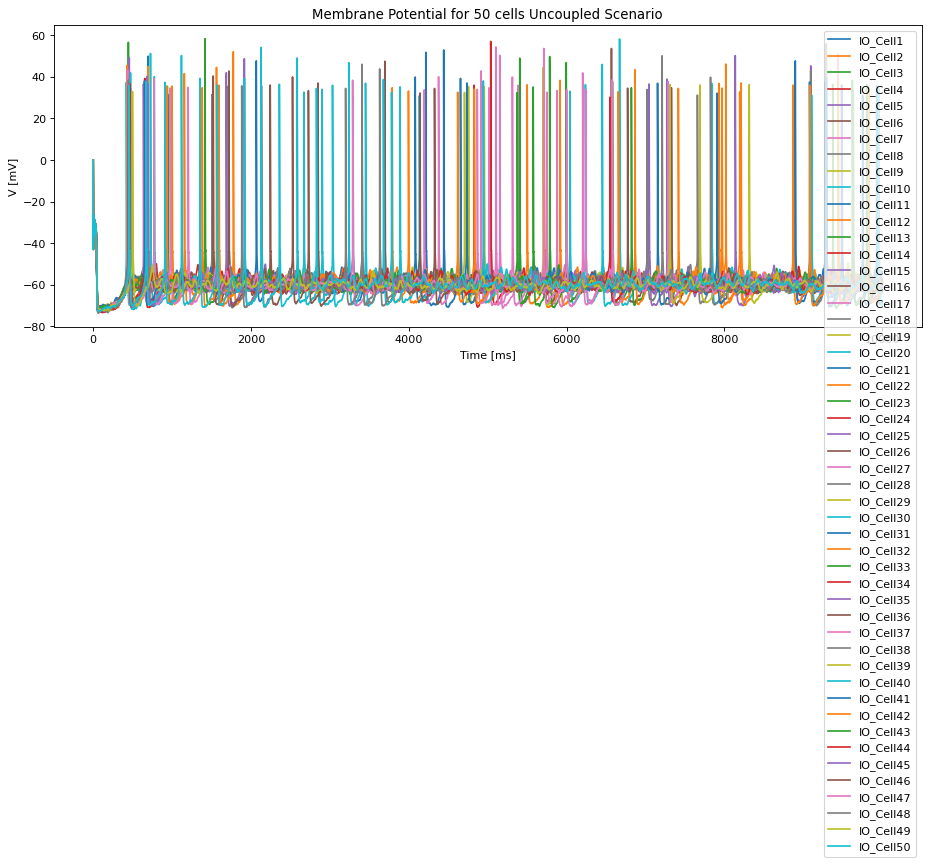

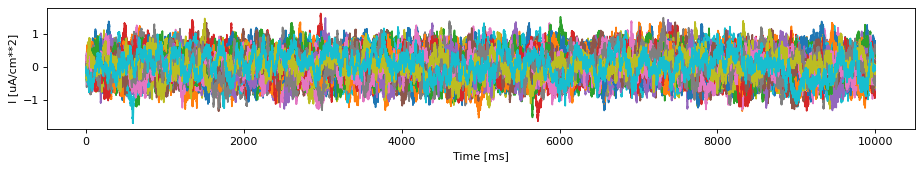

In [10]:
time = IO_Statemon.t/ms
IO_plot_neurons(N_Cells_IO,IO_Statemon, time, "Uncoupled") #Membrane potential for the uncoupled scenario (0% strength)
plt.figure(figsize=(14, 2), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,N_Cells_IO):
    plot(IO_Statemon.t/ms,IO_Statemon.I_OU[ii]/(uA/cm**2))
ylabel('I [uA/cm**2]')
xlabel('Time [ms]')
show()

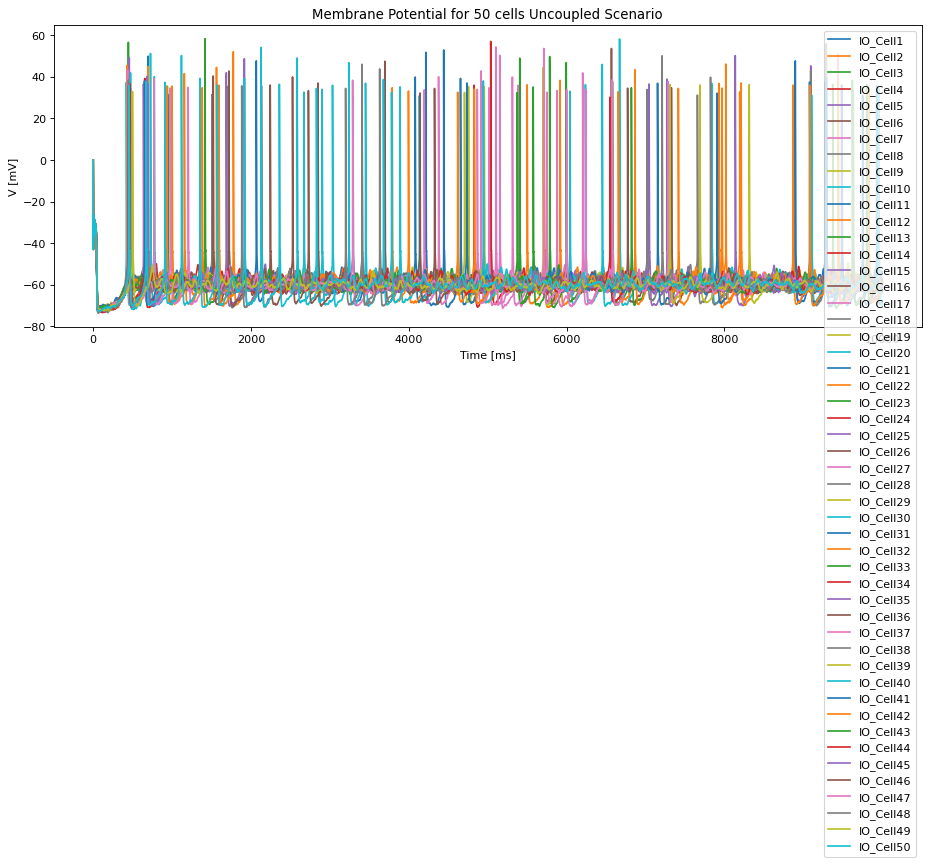

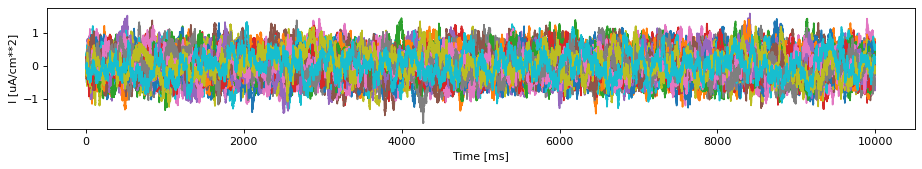

In [11]:
time = IO_Statemon.t/ms
IO_plot_neurons(N_Cells_IO,IO_Statemon, time, "Uncoupled") #Membrane potential for the uncoupled scenario (0% strength)
plt.figure(figsize=(14, 2), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,N_Cells_IO):
    plot(IO_Statemon_Coupled.t/ms,IO_Statemon_Coupled.I_OU[ii]/(uA/cm**2))
ylabel('I [uA/cm**2]')
xlabel('Time [ms]')
show()

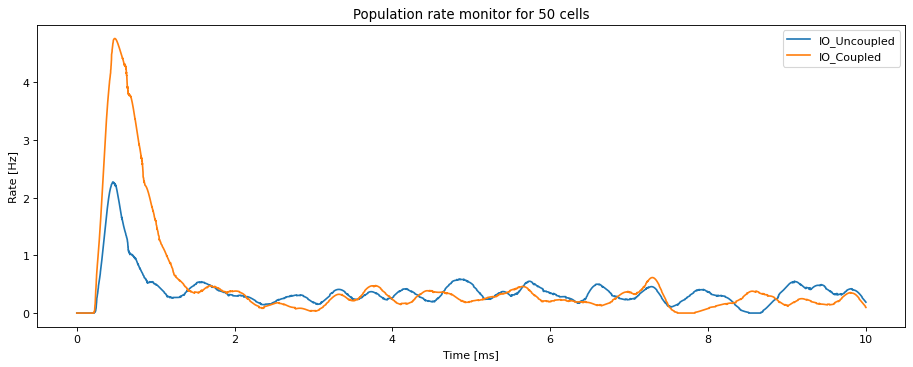

In [12]:
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
plot(IO_rate.t, IO_rate.smooth_rate(window='gaussian', width=width)/Hz, label='IO_Uncoupled')
plot(IO_rate_Coupled.t, IO_rate_Coupled.smooth_rate(window='gaussian', width=width)/Hz, label='IO_Coupled')
title('Population rate monitor for '+str(N_Cells_IO)+" cells")
ylabel('Rate [Hz]')
xlabel('Time [ms]')
legend()
show()

In [13]:
# IO_plot_neurons(N_Cells_IO,IO_Statemon_Coupled,time,"Coupled") #Membrane potential for the uncoupled scenario (0% strength)
# plt.figure(figsize=(14, 0.5), dpi= 80, facecolor='w', edgecolor='k')
# plot(IO_Statemon_Coupled.t/ms,IO_Statemon_Coupled.Iapp_s[0]/(uA/cm**2))
# ylabel('V [mV]')
# xlabel('Time [ms]')
# show()

In [14]:
# time_interval = 300
# IO_spikes_times,time_range_all_spikes, Vs_range_all_spikes, time_range, Vs_range = CS_calculations(N_Cells_IO,IO_Statemon,IO_Spikemon,time_interval,dt_rec)
# IO_spikes_times_Coupled,time_range_all_spikes_Coupled, Vs_range_all_spikes_Coupled, time_range_Coupled, Vs_range_Coupled = CS_calculations(N_Cells_IO,IO_Statemon_Coupled,IO_Spikemon_Coupled,time_interval,dt_rec)

In [15]:
# CS_averages_spikes(N_Cells_IO,time_range,Vs_range,'Uncoupled')
# CS_averages_spikes(N_Cells_IO,time_range_Coupled,Vs_range_Coupled,'Coupled')